<a href="https://colab.research.google.com/github/Pratik-sharma-py/datascience/blob/main/pca_step_by_step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = np.array([
    [2,  55, 8, 3],
    [3,  60, 7, 4],
    [5,  72, 7, 5],
    [6,  75, 6, 6]
])
labels = list('ABCD')
features = ['Study hrs', 'Exam score', 'Sleep hrs', 'Stress']

df = pd.DataFrame(data, columns=features, index=labels)
print(df)

   Study hrs  Exam score  Sleep hrs  Stress
A          2          55          8       3
B          3          60          7       4
C          5          72          7       5
D          6          75          6       6


In [ ]:
n = df.shape[0]
print(n)

4


In [ ]:
# Mean of each Feature

df_mean = df.mean()
print(df_mean)

Study hrs      4.0
Exam score    65.5
Sleep hrs      7.0
Stress         4.5
dtype: float64


In [ ]:
# Scaled the Matrix

df_scaled = df.sub(df_mean, axis=1) # df - df_mean , columns-wise
print(df_scaled)

   Study hrs  Exam score  Sleep hrs  Stress
A       -2.0       -10.5        1.0    -1.5
B       -1.0        -5.5        0.0    -0.5
C        1.0         6.5        0.0     0.5
D        2.0         9.5       -1.0     1.5


In [ ]:
# Covraince Matrix

df_cov = df_scaled.cov()
print(df_cov)

            Study hrs  Exam score  Sleep hrs     Stress
Study hrs    3.333333   17.333333  -1.333333   2.333333
Exam score  17.333333   91.000000  -6.666667  12.000000
Sleep hrs   -1.333333   -6.666667   0.666667  -1.000000
Stress       2.333333   12.000000  -1.000000   1.666667


In [ ]:
cov_data = np.cov(-2, 2)
cov_data

/tmp/ipykernel_1995/2987850242.py:1: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_data = np.cov(-2, 2)


array([[nan, nan],
       [nan, nan]])

In [ ]:
# Eigen value and Eigen Vector

eigen_values, eigen_vectors = np.linalg.eig(df_cov)
print("Eigen Values:",eigen_values)
print("Eigen Vectors",eigen_vectors)



Eigen Values: [9.63819438e+01 2.76380548e-01 8.34227173e-03 1.17685929e-16]
Eigen Vectors [[-1.85244175e-01  2.68213926e-01  8.52689403e-01 -4.08248290e-01]
 [-9.71630869e-01 -1.78753506e-01 -1.54856831e-01 -1.11067336e-14]
 [ 7.15972652e-02 -7.86224219e-01  4.58321548e-01  4.08248290e-01]
 [-1.28420720e-01  5.27219073e-01  1.97183928e-01  8.16496581e-01]]


In [ ]:
# Sort by eigenvalues (descending)

sorted_indices = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_indices]
eigen_vectors = eigen_vectors[:, sorted_indices]
print("Eigen Values:",eigen_values)
print("Eigen Vectors",eigen_vectors)

Eigen Values: [9.63819438e+01 2.76380548e-01 8.34227173e-03 1.17685929e-16]
Eigen Vectors [[-1.85244175e-01  2.68213926e-01  8.52689403e-01 -4.08248290e-01]
 [-9.71630869e-01 -1.78753506e-01 -1.54856831e-01 -1.11067336e-14]
 [ 7.15972652e-02 -7.86224219e-01  4.58321548e-01  4.08248290e-01]
 [-1.28420720e-01  5.27219073e-01  1.97183928e-01  8.16496581e-01]]


In [ ]:
# Form projection Matrix

k = 1
#W = eigen_vectors[:,sorted_indices]
W = W[:,:k]
print(W)



[[-0.18524418]
 [-0.97163087]
 [ 0.07159727]
 [-0.12842072]]


In [ ]:
# Step 6: Transform
Z = df_scaled.dot(W)
print(Z)


           0
A  10.836841
B   5.593424
C  -6.565055
D  -9.865210


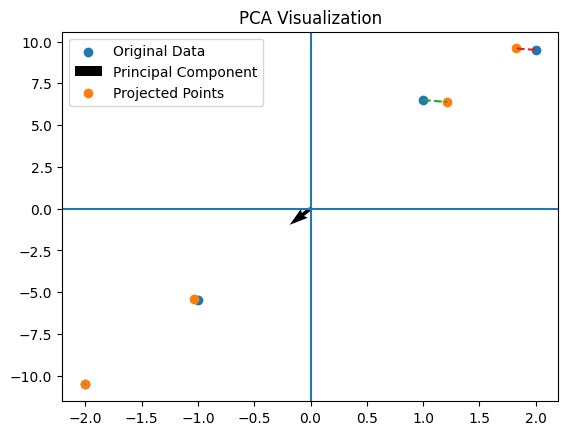

In [ ]:
import matplotlib.pyplot as plt

# Original points
plt.scatter(df_scaled.iloc[:, 0], df_scaled.iloc[:, 1], label='Original Data')

# Principal component direction
origin = np.array([0, 0])
pc1 = W[:, 0]

plt.quiver(*origin, pc1[0], pc1[1],
           angles='xy', scale_units='xy', scale=1,
           label='Principal Component')

# Projected points (back to 2D for visualization)
projected = Z.dot(W.T)

plt.scatter(projected.iloc[:, 0], projected.iloc[:, 1],
            label='Projected Points')

# Draw lines from original to projection
for i in range(len(df_scaled)):
    plt.plot([df_scaled.iloc[i, 0], projected.iloc[i, 0]],
             [df_scaled.iloc[i, 1], projected.iloc[i, 1]],
             linestyle='dashed')

plt.axhline(0)
plt.axvline(0)
plt.legend()
plt.title("PCA Visualization")
plt.show()

# NEXT PRACTISE


Explained variance ratio: [0.97454036 0.02035449]
Cumulative: [0.97454036 0.99489485]


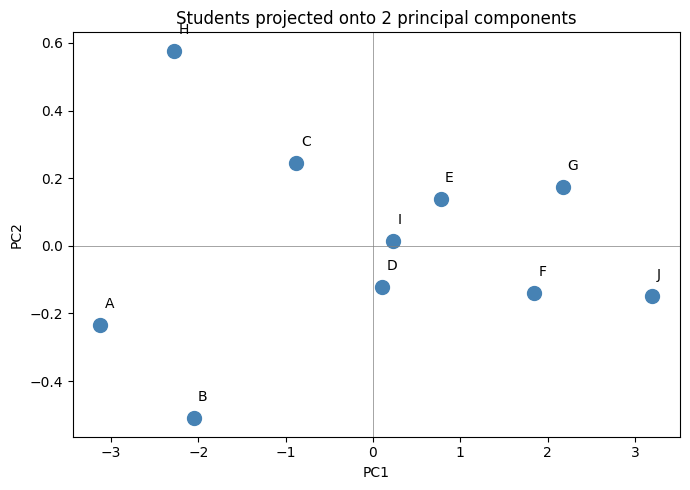

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = np.array([
    [2,  55, 8, 3],
    [3,  60, 7, 4],
    [5,  72, 7, 5],
    [6,  75, 6, 6],
    [7,  80, 6, 7],
    [8,  85, 5, 8],
    [9,  88, 5, 8],
    [4,  65, 8, 3],
    [6,  78, 6, 6],
    [10, 92, 4, 9],
])
labels = list('ABCDEFGHIJ')
features = ['Study hrs', 'Exam score', 'Sleep hrs', 'Stress']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.cumsum())

plt.figure(figsize=(7, 5))
for i, label in enumerate(labels):
    plt.scatter(X_pca[i, 0], X_pca[i, 1], s=100, color='steelblue')
    plt.annotate(label, (X_pca[i, 0] + 0.05, X_pca[i, 1] + 0.05))
plt.axhline(0, color='gray', lw=0.5); plt.axvline(0, color='gray', lw=0.5)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Students projected onto 2 principal components')
plt.tight_layout(); plt.show()



Original data (first row): [ 3 55  8  3]
Standardised  (first row): [-1.35 -1.74  1.44 -1.43]

Covariance matrix:
[[ 1.11  1.09 -1.05  1.08]
 [ 1.09  1.11 -1.04  1.07]
 [-1.05 -1.04  1.11 -1.09]
 [ 1.08  1.07 -1.09  1.11]]

Variance explained by each PC:
  PC1: 97.3%
  PC2: 1.9%
  PC3: 0.5%
  PC4: 0.3%


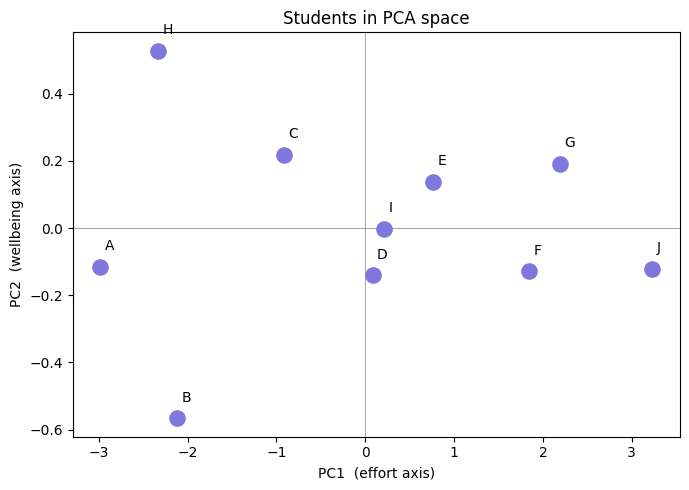

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Step 0: Our data ---
data = np.array([
    [3,  55, 8, 3],   # Student A
    [3,  60, 7, 4],   # Student B
    [5,  72, 7, 5],   # Student C
    [6,  75, 6, 6],   # Student D
    [7,  80, 6, 7],   # Student E
    [8,  85, 5, 8],   # Student F
    [9,  88, 5, 8],   # Student G
    [4,  65, 8, 3],   # Student H
    [6,  78, 6, 6],   # Student I
    [10, 92, 4, 9],   # Student J
])
labels = list('ABCDEFGHIJ')

# --- Step 1: Standardise ---
scaler = StandardScaler()
X = scaler.fit_transform(data)
print("Original data (first row):", data[0])
print("Standardised  (first row):", X[0].round(2))
# Notice: each number is now "how many standard deviations from the average"

# --- Step 2: Covariance matrix ---
cov = np.cov(X.T)
print("\nCovariance matrix:")
print(cov.round(2))
# Look at the off-diagonal numbers — large positive = features move together

# --- Step 3 & 4: PCA finds eigenvectors ---
pca = PCA()
pca.fit(X)
print("\nVariance explained by each PC:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:.1f}%")

# --- Step 5: Project ---
X_pca = pca.transform(X)

# --- Visualise ---
plt.figure(figsize=(7, 5))
for i, label in enumerate(labels):
    plt.scatter(X_pca[i, 0], X_pca[i, 1], s=120, color='#7F77DD', zorder=3)
    plt.annotate(label, (X_pca[i,0]+0.05, X_pca[i,1]+0.05), fontsize=10)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.xlabel('PC1  (effort axis)')
plt.ylabel('PC2  (wellbeing axis)')
plt.title('Students in PCA space')
plt.tight_layout()
plt.show()